<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# SpiceManager, Celestial Bodies, and SCB Constants
---
*Last revised 2026 MAY*

## Introduction
This tutorial will explore the core infrastructure within Scarabaeus (SCB) for SPICE kernel interaction and planetary body representations. In addition, it will show 
how to interface with its constants library, which contains physical parameters and planetary constants.

## Imports and Setup
First we'll import the necessary libraries, define units, and load in supplementary data, which for this tutorial is the general metakernel which contains kernels for planetary epehemerides and leapseconds for time conversions.

In [1]:
import scarabaeus as scb
import supplementary as supp

from dataclasses import fields
import numpy as np

# load tutorial data
data = supp.load_data()

## define the units and frames we'll be using across the tutorial
km, AU, kg, sec, day = scb.Units.get_units(['km', 'AU', 'kg', 'sec', 'day'])

J2000, ECLIPJ2000 = scb.Frame('J2000'), scb.Frame('ECLIPJ2000')
IAU_EARTH, IAU_JUPITER = scb.Frame('IAU_EARTH'), scb.Frame('IAU_JUPITER')

# load kernels
scb.SpiceManager.clear_kernels()    # make sure kernel pool is empty
scb.SpiceManager.load_kernel_from_mkfile(data.mk.path)

SCB supplementary data up to date.


## SpiceManager

`SpiceManager` is Scarabaeus' interface with the SPICE toolkit. It handles kernel management, reference frame rotations, and state vectors.
We saw above how to use it to clear, load, and examine kernels in the kernel pool.

### Reference Frame Transformations

`get_xfrm(from_frame, to_frame, et)` returns the 3×3 rotation matrix that maps vectors
expressed in `from_frame` into `to_frame` at epoch `et`.
Frame names follow the SPICE convention (`"J2000"`, `"ECLIPJ2000"`, `"IAU_EARTH"`, …).

In [2]:
et = 140254384.184625   # seconds past J2000
print("ECLIPJ2000 to J2000 :")
print(scb.SpiceManager.get_xfrm(ECLIPJ2000.name, J2000.name, et))

print("\nECLIPJ2000 to IAU_EARTH :")
print(scb.SpiceManager.get_xfrm(ECLIPJ2000.name, IAU_EARTH.name, et))

ECLIPJ2000 to J2000 :
[[ 1.          0.          0.        ]
 [ 0.          0.91748206 -0.39777716]
 [ 0.          0.39777716  0.91748206]]

ECLIPJ2000 to IAU_EARTH :
[[-9.72925256e-01 -2.11880898e-01  9.23197279e-02]
 [ 2.31119580e-01 -8.92681357e-01  3.86915668e-01]
 [ 4.32060908e-04  3.97776922e-01  9.17482062e-01]]


### Body State Queries

For any body in the kernel pool, `SpiceManager` returns its position, velocity, or full
state relative to an observer in a chosen reference frame.

It contains a few different methods that return different information depending on what you need:

- `get_pos(target, et, frame, observer)`      : 3-vector position (km)
- `get_vel(target, et, frame, observer)`      : 3-vector velocity (km/s)
- `get_state(target, et, frame, observer)`    : 6-vector [pos; vel]
- `get_lighttime(target, et, frame, observer)`: one-way light-time (s)

We can see all of these values by getting the state of the Earth with respect to the Sun in J2000:

In [3]:
# Earth w.r.t. the Sun at the reference epoch
print(f"Position only:\n{scb.SpiceManager.get_pos('Earth', et, J2000.name, 'Sun')}\n")
print(f"Velocity only:\n{scb.SpiceManager.get_vel('Earth', et, J2000.name, 'Sun')}\n")
print(f"Full state vector:\n{scb.SpiceManager.get_state('Earth', et, J2000.name, 'Sun')}\n")
print(f"Light time:\n{scb.SpiceManager.get_lighttime('Earth', et, J2000.name, 'Sun')}\n")

Position only:
[-2.34128283e+07 -1.37716948e+08 -5.97056600e+07] [km ... km]

Velocity only:
[28.94979026 -4.32365438 -1.87551229] [km/sec ... km/sec]

Full state vector:
[-2.34128283e+07 -1.37716948e+08 -5.97056600e+07  2.89497903e+01
 -4.32365438e+00 -1.87551229e+00] [non-homogeneous]

Light time:
506.7417668236853 sec



## CelestialBody

A `CelestialBody` contains physical constants of a planet or natural satellite
(mass, mean radius, gravitational parameter) with a SPICE identifier for ephemeris queries.
There are two ways to create one.

### From Constants
This is the faster of the two. It pulls the necessary values from Scarabaeus' constants library. We can also view all the properties of the body using `disp_properties()`:

In [4]:
# create from constants and display
jupiter_from_constants = scb.CelestialBody.from_constants('JUPITER')
jupiter_from_constants.disp_properties()

                           Jupiter                            
mass                     : <bound method Body.mass of Jupiter>
mean_radius              : 69911.0 km
gravitational parameter  : 126686534.92180079 mu
reference frame          : IAU_JUPITER
SPICE ID                 : 599
attached ground stations : []


### Direct Construction

We can also give values directly to the initialization of `CelestialBody`. As an example, we'll create a planet with values half that of Jupiter. We can access the same constants library the `from_constants()` pulled from directly and divide those by two to pass to the constructor:

In [5]:
# get planetary constants for Jupiter
jov_pc = scb.constants.JUPITER

# create a half sized Jupiter
half_jupiter = scb.CelestialBody(name        = 'HALF_JUPITER',
                                 mass        = jov_pc.mass / 2,
                                 mean_radius = jov_pc.mean_radius / 2,
                                 grav_param  = jov_pc.GM / 2,
                                 base_frame  = jov_pc.ref_name,
                                 spice_id    = 599000)  # give it a different ID than the actual Jupiter
half_jupiter.disp_properties()

                            HALF_JUPITER                           
mass                     : <bound method Body.mass of HALF_JUPITER>
mean_radius              : 34955.5 km
gravitational parameter  : 63343267.460900396 mu
reference frame          : IAU_JUPITER
SPICE ID                 : 599000
attached ground stations : []


All major and minor bodies contained within the constants library hold their information as a `PCInfo` object, which we then pulled values from directly. Depending on the kind of body, some of these parameters may or may not exist. For example, the Moon's primary is Earth, but the Earth is defined without a primary (even though the Sun is technically its primary). Below are all of the parameters contained within a `PCInfo` data class:

In [6]:
phobos = scb.constants.PHOBOS

print('All PCInfo fields for Phobos:')
for field in fields(phobos):
    print(f' - {field.name}: {getattr(phobos, field.name)}')

All PCInfo fields for Phobos:
 - name: Phobos
 - spice_name: PHOBOS
 - ref_name: IAU_PHOBOS
 - body_center_id: 401
 - barycenter_id: None
 - mass: 1.0619160161956238e+16 kg
 - GM: 0.0007087546066894452 mu
 - mean_radius: 11.4 km
 - equatorial_radius: None
 - GM_barycenter: None
 - primary_body: Mars


### Querying Ephemerides

If the body exists in the kernel pool, `get_state` returns its position and velocity at any epoch.
Below we query all eight planets' heliocentric orbits over two years and plot them.

Querying MERCURY...


Retrieved all states across 728.0 day interval
Querying VENUS...


Retrieved all states across 728.0 day interval
Querying EARTH...


Retrieved all states across 728.0 day interval
Querying MARS...


Retrieved all states across 728.0 day interval
Querying JUPITER...


Retrieved all states across 728.0 day interval
Querying SATURN...


Retrieved all states across 728.0 day interval
Querying URANUS...


Retrieved all states across 728.0 day interval
Querying NEPTUNE...


Retrieved all states across 728.0 day interval


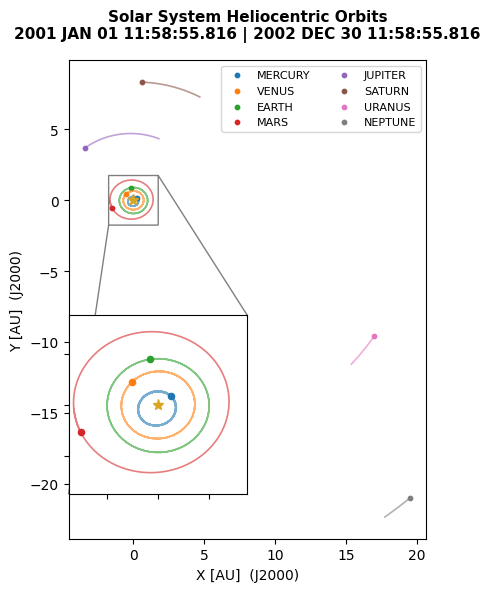

In [7]:
# 2 year time interval with weekly sample rate
epochs = scb.EpochArray.interval(start = '2001 JAN 01 12:00:00.000', 
                                 end   = '2003 JAN 01 12:00:00.000',
                                 dt    = scb.ArrayWUnits(7, day),
                                 sys   = 'TDB')

# query heliocentric state for each planet
planets = ['MERCURY', 'VENUS', 'EARTH', 'MARS', 
           'JUPITER', 'SATURN', 'URANUS', 'NEPTUNE']
planet_traj  = {}
for planet in planets:
    cb     = scb.CelestialBody.from_constants(planet)
    states = []
    print(f'Querying {planet}...')
    for epoch in epochs:
        state = cb.get_state(epoch_0 = epoch, reference_frame = 'J2000',
                             origin = 'SUN').quantity
        states.append(state[0:2].convert_to(AU).values)
    planet_traj[planet] = np.array(states)
    print(f'Retrieved all states across {epochs.duration(day)} interval')

supp.supp_plotting.plot_planets(planets, planet_traj, epochs)